# DC Motor Control: PID vs LQR

This notebook demonstrates closed-loop control of a 1st order DC motor model using two strategies:
- **PID** (Proportional-Integral-Derivative) control
- **LQR** (Linear Quadratic Regulator) with integral action

Both controllers use the same motor parameters and simulation settings for a fair comparison.

## 1. Import Required Libraries
Import numpy, AILibs, and motor_model modules needed for simulation and control.

In [1]:
import numpy
import matplotlib.pyplot as plt

import AILibs
import motor_model

## 2. Define Motor Parameters

Define shared motor parameters for a 1st order DC motor and common simulation settings.

In [2]:
# Time step
dt = 0.001

# 1st order DC motor, some random params
b  = 0.0001  # Viscous friction
Kt = 0.05    # Torque constant
Ke = 0.05    # Back EMF constant
R  = 2.0     # Armature resistance
J  = 0.0001  # Rotor inertia

# Simulation settings
n_steps = 1000
rpm_req = 5000

## 3. Create DC Motor Dynamical System

Instantiate the `MotorModel` dynamical system using the defined parameters and print the system matrices.

In [3]:
# Create dynamical system
ds = motor_model.MotorModel(b, Kt, Ke, R, J, dt)

# Print matrices
print(str(ds))

mat_a = 
-13.5 


mat_b = 
250.0 


mat_c = 
1.0 





## 4. Define Simulation Helper Functions

- `compute_cost(x)`: computes the sum of squared values (used for control effort and tracking error metrics).
- `run_simulation(ds, controller_fn, n_steps)`: runs the closed-loop simulation loop with a step reference applied at 10% of `n_steps`, converts states to RPM, and returns logged results.

In [4]:
def compute_cost(x):
    """Return sum of squared values."""
    return numpy.sum(numpy.square(x))


def run_simulation(ds, controller_fn, n_steps):
    """
    Run a closed-loop simulation.

    Parameters
    ----------
    ds : AILibs.DynamicalSystem
        The motor dynamical system.
    controller_fn : callable
        A function with signature (xr, x, state) -> (u_in, state)
        where state is an arbitrary dict carried across steps.
    n_steps : int
        Number of simulation steps.

    Returns
    -------
    t_result, u_result, xr_result, x_result : lists
    """
    t_result  = []
    u_result  = []
    xr_result = []
    x_result  = []

    x = numpy.zeros((ds.a.shape[0], 1))
    state = {}  # mutable controller state (e.g. integral action, previous u)

    for n in range(n_steps):
        # Step reference after 10% of simulation
        if n > n_steps * 0.1:
            xr = numpy.ones(x.shape)
        else:
            xr = numpy.zeros(x.shape)

        xr = xr * rpm_req / (2.0 * numpy.pi * 60.0)

        # Controller produces u_in (matrix) and updated state
        u_in, state = controller_fn(xr, x, state)

        # Process simulation step
        x, _ = ds.forward(x, u_in)

        # Convert to RPM
        xr_rpm = xr[:, 0] * (60.0 * 2.0 * numpy.pi)
        x_rpm  = x[:, 0]  * (60.0 * 2.0 * numpy.pi)

        # Log results
        t_result.append(n * dt)
        u_result.append(u_in[:, 0])
        xr_result.append(xr_rpm)
        x_result.append(x_rpm)

    return t_result, u_result, xr_result, x_result

## 5. PID Controller Design and Simulation

Create a PID controller with `kp=0.1`, `ki=0.0015`, `kd=0.0` and run the closed-loop simulation.

In [5]:
# PID gains
kp = 0.1
ki = 0.0015
kd = 0.0

pid_controller = AILibs.PID(kp, ki, kd)

# --- PID simulation loop ---
t_result_pid  = []
u_result_pid  = []
xr_result_pid = []
x_result_pid  = []

x = numpy.zeros((ds.a.shape[0], 1))
u = 0.0

for n in range(n_steps):
    # Step reference after 10% of simulation
    if n > n_steps * 0.1:
        xr = numpy.ones(x.shape)
    else:
        xr = numpy.zeros(x.shape)

    xr = xr * rpm_req / (2.0 * numpy.pi * 60.0)

    # PID takes scalar inputs
    u = pid_controller.forward(xr[0, 0], x[0, 0], u)

    # Wrap scalar u into matrix for ds.forward
    u_in = numpy.array([[u]])

    # Process simulation step
    x, _ = ds.forward(x, u_in)

    # Convert to RPM
    xr_rpm = xr[:, 0] * (60.0 * 2.0 * numpy.pi)
    x_rpm  = x[:, 0]  * (60.0 * 2.0 * numpy.pi)

    # Log results
    t_result_pid.append(n * dt)
    u_result_pid.append(u_in[:, 0])
    xr_result_pid.append(xr_rpm)
    x_result_pid.append(x_rpm)

print("PID simulation complete")

PID simulation complete


## 6. Plot PID Closed-Loop Response

Visualise the PID closed-loop response and compute control-effort / tracking-error costs.

PID  u_cost = 508.955,  x_cost = 461440085.418


<Figure size 640x480 with 0 Axes>

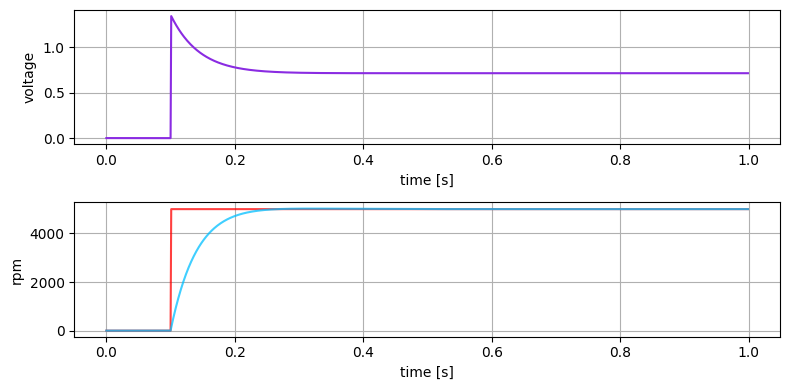

In [6]:
# Plot PID closed-loop response
AILibs.plot_cl_response(
    t_result_pid, u_result_pid, xr_result_pid, x_result_pid,
    "plots/pid_result.png", ["voltage"], ["rpm"]
)

# Compute costs
u_cost_pid = compute_cost(numpy.array(u_result_pid))
x_cost_pid = compute_cost(numpy.array(xr_result_pid) - numpy.array(x_result_pid))

print(f"PID  u_cost = {round(u_cost_pid, 3)},  x_cost = {round(x_cost_pid, 3)}")

## 7. LQR Controller Design and Simulation

Discretise the continuous motor model, design an LQR controller with integral action, and run the closed-loop simulation.

In [7]:
# Discretise continuous system
a_disc, b_disc, _ = AILibs.c2d(ds.a, ds.b, None, dt)

# LQR cost matrices
q  = numpy.diag([1.0])
r  = numpy.diag([100000.0])
qi = 1.0

# Create LQR controller with integral action
lqr_controller = AILibs.LQRIDiscrete(a_disc, b_disc, q, r, qi)

print("k  = ", lqr_controller.k)
print("ki = ", lqr_controller.ki)

# --- LQR simulation loop ---
t_result_lqr  = []
u_result_lqr  = []
xr_result_lqr = []
x_result_lqr  = []

x = numpy.zeros((ds.a.shape[0], 1))
integral_action = numpy.zeros((ds.b.shape[0], 1))

for n in range(n_steps):
    # Step reference after 10% of simulation
    if n > n_steps * 0.1:
        xr = numpy.ones(x.shape)
    else:
        xr = numpy.zeros(x.shape)

    xr = xr * rpm_req / (2.0 * numpy.pi * 60.0)

    # LQR controller forward pass
    u, integral_action = lqr_controller.forward(xr, x, integral_action)

    # Process simulation step
    x, _ = ds.forward(x, u)

    # Convert to RPM
    xr_rpm = xr[:, 0] * (60.0 * 2.0 * numpy.pi)
    x_rpm  = x[:, 0]  * (60.0 * 2.0 * numpy.pi)

    # Log results
    t_result_lqr.append(n * dt)
    u_result_lqr.append(u[:, 0])
    xr_result_lqr.append(xr_rpm)
    x_result_lqr.append(x_rpm)

print("LQR simulation complete")

k  =  [[0.11639621]]
ki =  [[0.00320765]]
LQR simulation complete


## 8. Plot LQR Closed-Loop Response

Visualise the LQR closed-loop response and compute control-effort / tracking-error costs.

LQR  u_cost = 490.843,  x_cost = 947210998.565


<Figure size 640x480 with 0 Axes>

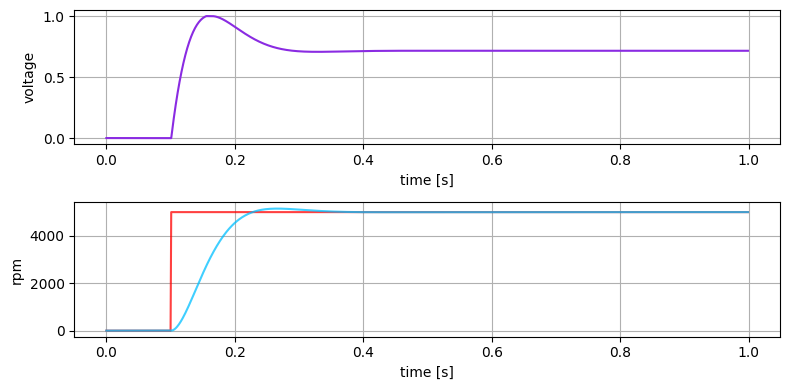

In [8]:
# Plot LQR closed-loop response
AILibs.plot_cl_response(
    t_result_lqr, u_result_lqr, xr_result_lqr, x_result_lqr,
    "plots/lqr_result.png", ["voltage"], ["rpm"]
)

# Compute costs
u_cost_lqr = compute_cost(numpy.array(u_result_lqr))
x_cost_lqr = compute_cost(numpy.array(xr_result_lqr) - numpy.array(x_result_lqr))

print(f"LQR  u_cost = {round(u_cost_lqr, 3)},  x_cost = {round(x_cost_lqr, 3)}")

## 9. Compare PID vs LQR Performance

Plot both responses side by side and print a summary comparison table of control effort (`u_cost`) and tracking error (`x_cost`).

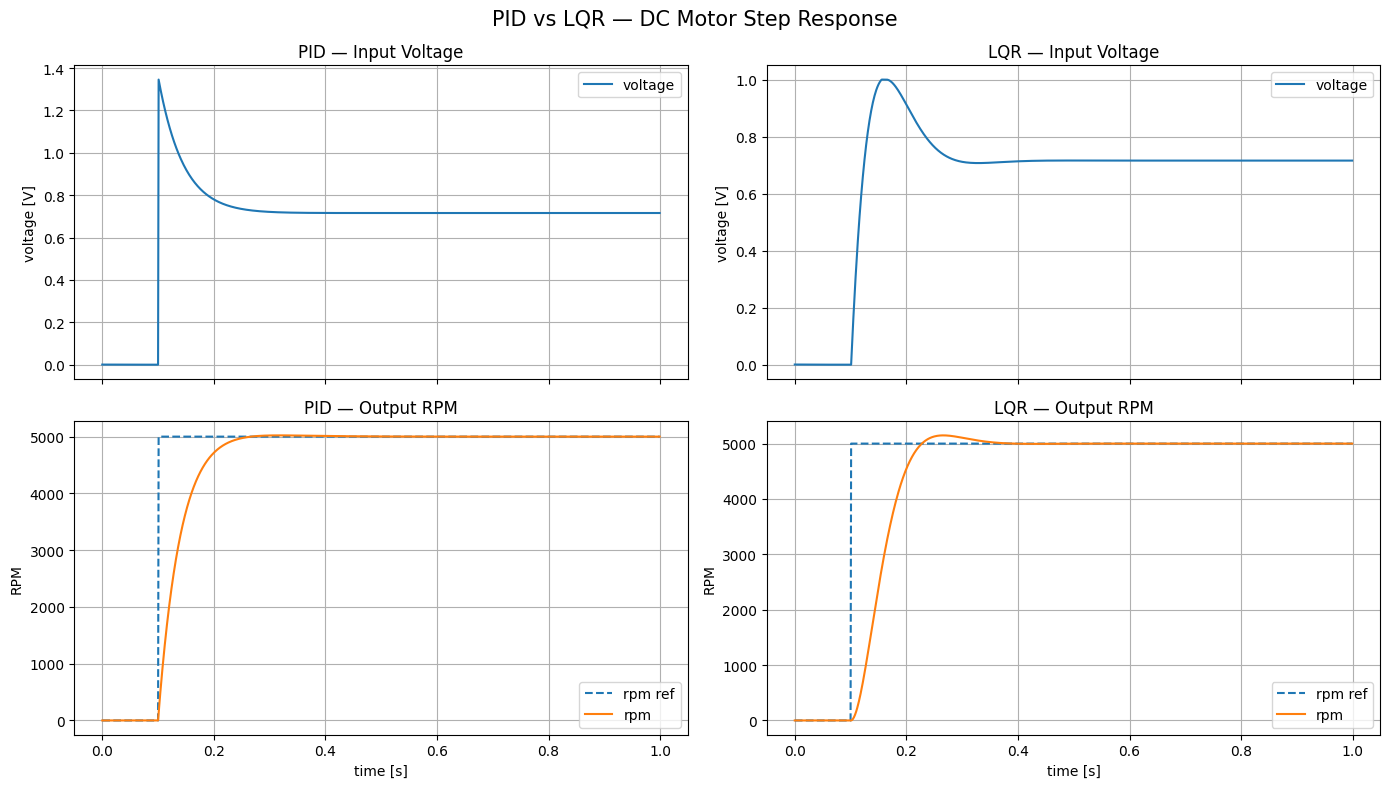


Controller         u_cost       x_cost
--------------------------------------------------
PID               508.955 461440085.418
LQR               490.843 947210998.565

u_cost = total control effort (sum of squared voltage)
x_cost = total tracking error (sum of squared RPM error)


In [9]:
# Convert lists to arrays for easy slicing
u_pid  = numpy.array(u_result_pid)
x_pid  = numpy.array(x_result_pid)
xr_pid = numpy.array(xr_result_pid)

u_lqr  = numpy.array(u_result_lqr)
x_lqr  = numpy.array(x_result_lqr)
xr_lqr = numpy.array(xr_result_lqr)

t = numpy.array(t_result_pid)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# --- PID column ---
axes[0, 0].set_title("PID — Input Voltage")
axes[0, 0].plot(t, u_pid, label="voltage")
axes[0, 0].set_ylabel("voltage [V]")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[1, 0].set_title("PID — Output RPM")
axes[1, 0].plot(t, xr_pid, "--", label="rpm ref")
axes[1, 0].plot(t, x_pid, label="rpm")
axes[1, 0].set_ylabel("RPM")
axes[1, 0].set_xlabel("time [s]")
axes[1, 0].legend()
axes[1, 0].grid(True)

# --- LQR column ---
axes[0, 1].set_title("LQR — Input Voltage")
axes[0, 1].plot(t, u_lqr, label="voltage")
axes[0, 1].set_ylabel("voltage [V]")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 1].set_title("LQR — Output RPM")
axes[1, 1].plot(t, xr_lqr, "--", label="rpm ref")
axes[1, 1].plot(t, x_lqr, label="rpm")
axes[1, 1].set_ylabel("RPM")
axes[1, 1].set_xlabel("time [s]")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle("PID vs LQR — DC Motor Step Response", fontsize=15)
plt.tight_layout()
plt.savefig("plots/pid_vs_lqr_comparison.png", dpi=150)
plt.show()

# --- Comparison table ---
print("\n" + "=" * 50)
print(f"{'Controller':<12} {'u_cost':>12} {'x_cost':>12}")
print("-" * 50)
print(f"{'PID':<12} {round(u_cost_pid, 3):>12} {round(x_cost_pid, 3):>12}")
print(f"{'LQR':<12} {round(u_cost_lqr, 3):>12} {round(x_cost_lqr, 3):>12}")
print("=" * 50)
print("\nu_cost = total control effort (sum of squared voltage)")
print("x_cost = total tracking error (sum of squared RPM error)")